## Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly 
from sklearn.linear_model import LogisticRegression, SGDClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,  RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

## Reading in the data

In [2]:
tdf = pd.read_csv("../input/titanic/train.csv") #Train
tedf = pd.read_csv("../input/titanic/test.csv") #Test

## Taking a look at the data and cleaning it!!

In [3]:
tdf.shape

(891, 12)

In [4]:
tedf.shape

(418, 11)

In [5]:
tdf.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The first thing I see is that there are NaN values in the cabin. Let's take a look at them.

In [6]:
tedf.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
tdf.Survived.value_counts()

0    549
1    342
Name: Survived, dtype: int64

Seems like there are more passengers deaths than survial

In [8]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


It seems like the Cabin column is almost filled with NaN values. The Age colum seems to be having a little bit of NaNs too along with the embarked

In [9]:
tedf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


There seems to be NaN values in the test data as well.

I will be filling out the missing data in the Age column in both the train and test set by using only the mean Age of the train set.

In [10]:
int(tdf.Age.mean())

29

The mean in the training set seems to be 29. So, I will be using this to fill in the missing values!!

In [11]:
tdf.Age.fillna(int(tdf.Age.mean()), inplace=True) #filling the missing value by using .fillna()

In [12]:
tedf.Age.fillna(int(tdf.Age.mean()), inplace=True) 

I think it's best to drop the Cabin column since it literally has NaN values for like more than 80% of it.

In [13]:
tdf.drop('Cabin', axis=1, inplace=True)
tedf.drop('Cabin', axis=1, inplace=True)

In [14]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [15]:
tedf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 32.8+ KB


NaN in the train is removed and in the test it is filled.

In [16]:
imp = SimpleImputer(strategy='most_frequent')
tedf[['Embarked']] = imp.fit_transform(tedf[['Embarked']])
tdf.dropna(axis=0, inplace=True)

In [17]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [18]:
tedf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 32.8+ KB


Now that our data is clean let's do some EDA!! 

## EDA

First let's take a look at the pairplot

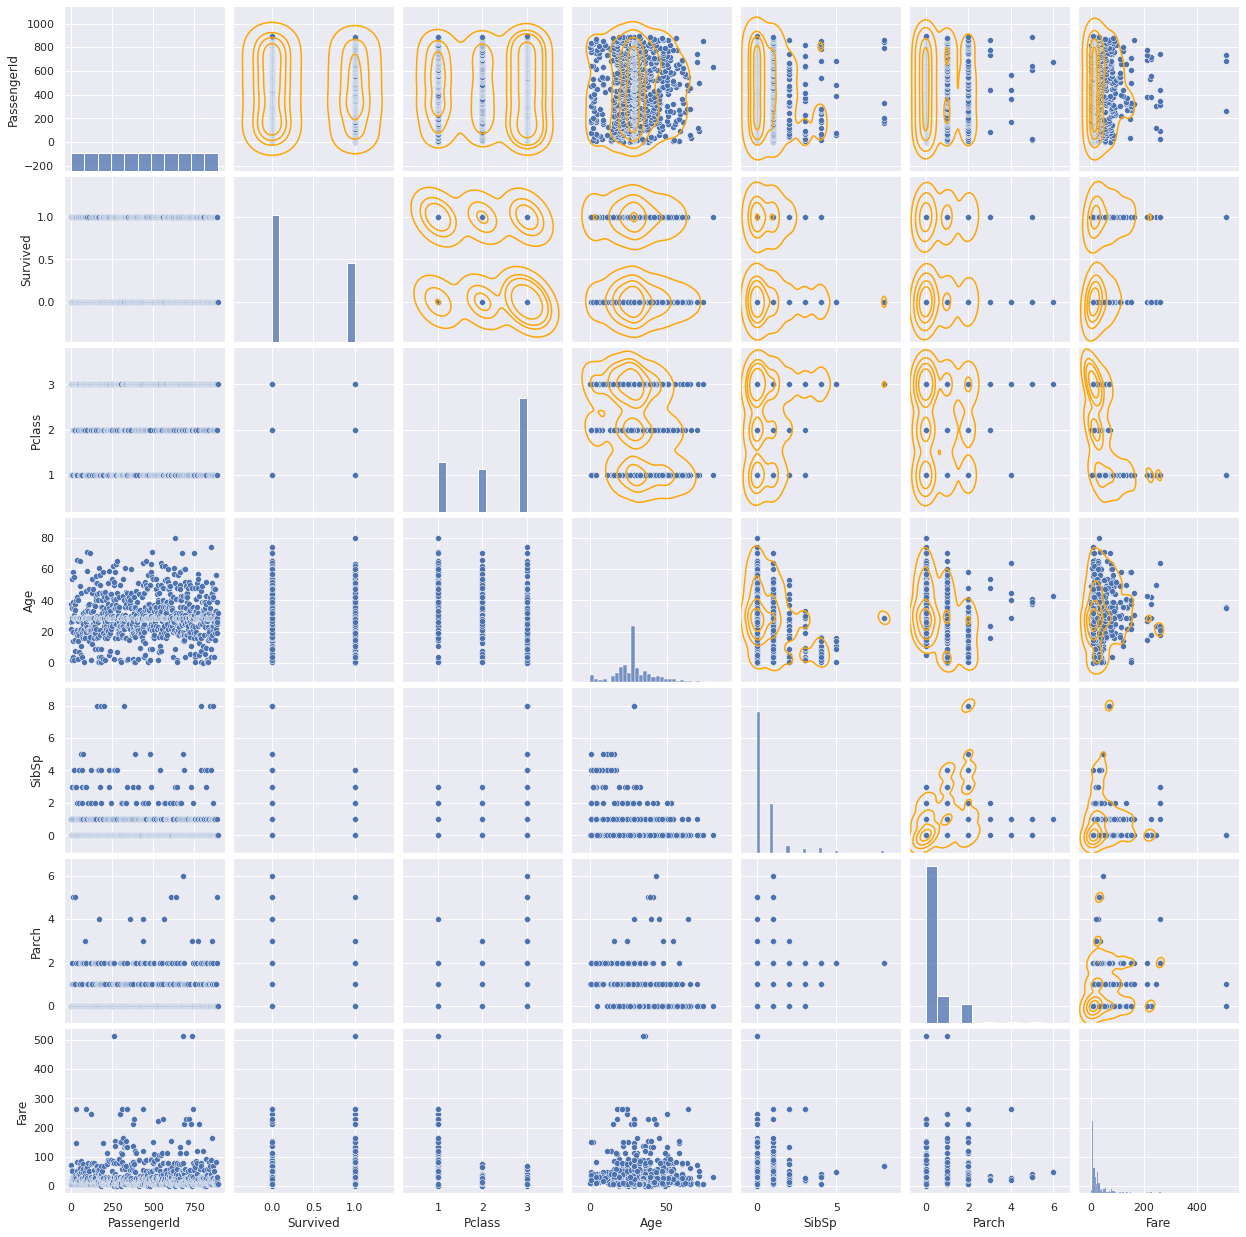

In [19]:
sns.set() #setting a style
g = sns.pairplot(tdf) # returns a pair grid
g.map_upper(sns.kdeplot, n_levels=5, color='orange')
plt.show()

Most of the passengers are in their 30s or 40s. There are a few old people on board. Also, most of these people have paid a very less fare. Fare did not play a role in the survival of person as we can see in the bottom left the survival rate it is quite the same no matter how much you paid. I think that the ones with less siblings survived.


As there is no use for the fare column I think it's better to drop it off. Along with the Name column

In [20]:
tdf.drop(['Fare', 'Name'], axis=1, inplace=True)
tedf.drop(['Fare', 'Name'], axis=1, inplace=True)

Let's take a look at the survived and the age relationship

In [21]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    object 
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Ticket       889 non-null    object 
 8   Embarked     889 non-null    object 
dtypes: float64(1), int64(5), object(3)
memory usage: 101.7+ KB


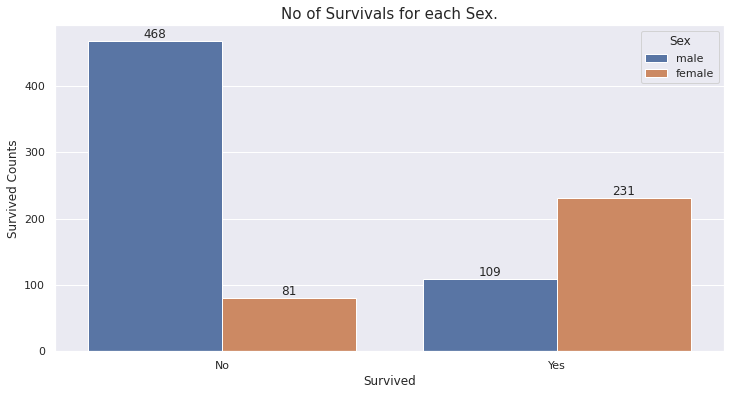

In [22]:
fig = plt.figure(figsize=(12,6))
g = sns.countplot(x='Survived', hue='Sex', data=tdf)
g.bar_label(g.containers[0])
g.bar_label(g.containers[1])
plt.ylabel("Survived Counts")
plt.title("No of Survivals for each Sex.",size=15)
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

There are more female survivors than male and more male deaths than female.

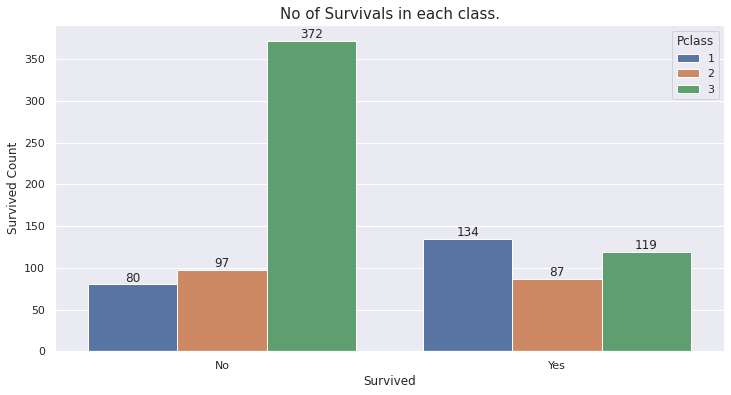

In [23]:
fig = plt.figure(figsize=(12, 6))
g = sns.countplot(x='Survived', hue='Pclass', data=tdf)
g.bar_label(g.containers[0])
g.bar_label(g.containers[1])
g.bar_label(g.containers[2])
plt.ylabel("Survived Count")
plt.xticks([0,1], ['No', 'Yes'])
plt.title("No of Survivals in each class.",size=15)
plt.show()

More of the 3rd class were killed than the others.

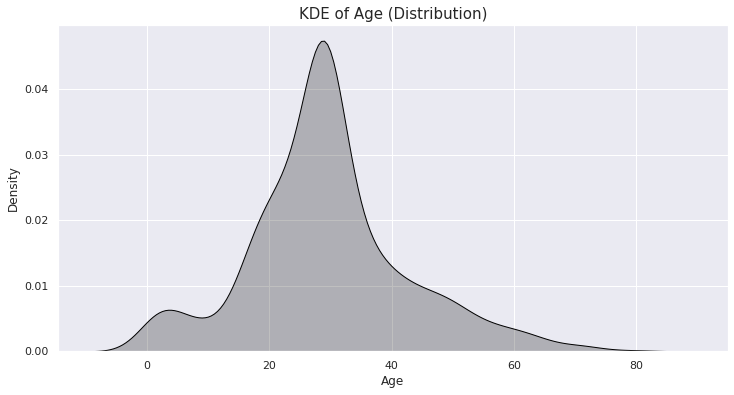

In [24]:
fig = plt.figure(figsize=(12, 6))
sns.kdeplot(data=tdf, fill=True, x='Age', color='black')
plt.title("KDE of Age (Distribution)", size=15)
plt.show()

As mentioned earlier, most of the passengers are in the early 30s or late 20s

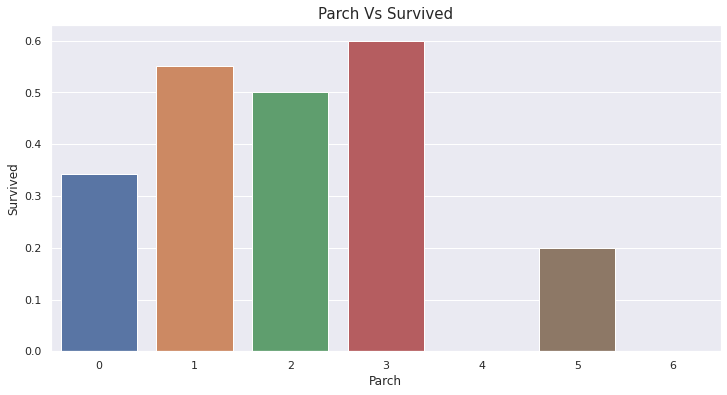

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Parch", y='Survived', data=tdf, ci=None) 
plt.title("Parch Vs Survived", size=15)
plt.show()

It seems like the one with 3 children (parch) had more chance of survival i.e 0.6. You can get an idea about others by looking at the above graph.

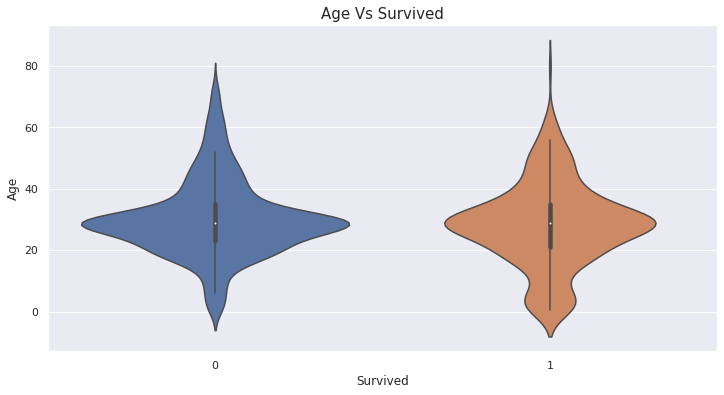

In [26]:
fig = plt.figure(figsize=(12, 6))
sns.violinplot(x='Survived', y='Age', data=tdf)
plt.title("Age Vs Survived", size=15)
plt.show()

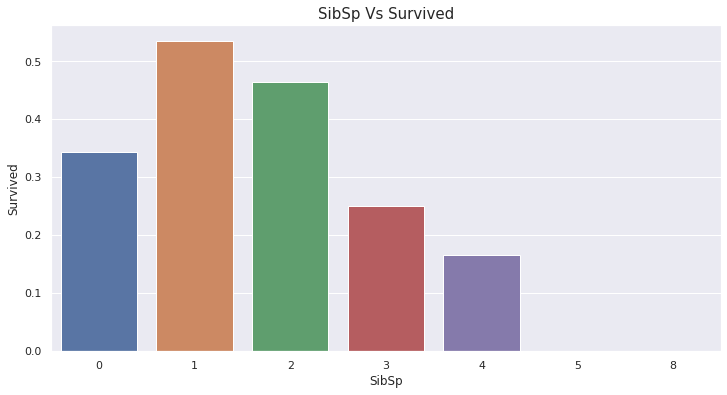

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(x="SibSp", y='Survived', data=tdf, ci=None) 
plt.title("SibSp Vs Survived", size=15)
plt.show()

The ones with one sibling or spouse had the most chance of survival and from then on it just goes downhill.

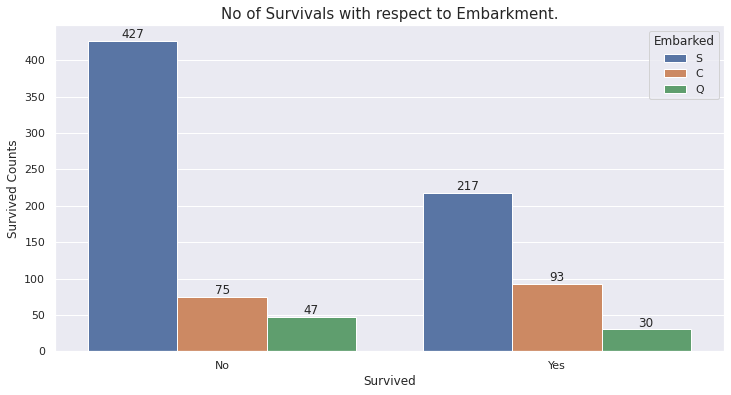

In [28]:
fig = plt.figure(figsize=(12,6))
g = sns.countplot(x='Survived', hue='Embarked', data=tdf)
g.bar_label(g.containers[0])
g.bar_label(g.containers[1])
g.bar_label(g.containers[2])
plt.ylabel("Survived Counts")
plt.title("No of Survivals with respect to Embarkment.",size=15)
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

Those who embarked from Southampton survived more and the same is true in terms of deaths. Followed by Cherbourg and, Queenstown being the least.

## Encoding the categorical variables

In [29]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    object 
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Ticket       889 non-null    object 
 8   Embarked     889 non-null    object 
dtypes: float64(1), int64(5), object(3)
memory usage: 101.7+ KB


In [30]:
tedf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    object 
 7   Embarked     418 non-null    object 
dtypes: float64(1), int64(4), object(3)
memory usage: 26.2+ KB


In [31]:
le = LabelEncoder()
for col in ['Sex', 'Ticket', 'Embarked']:
    tdf[col] = le.fit_transform(tdf[col])

In [32]:
for col in ['Sex', 'Ticket', 'Embarked']:
    tedf[col] = le.fit_transform(tedf[col])

In [33]:
tedf.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Embarked
0,892,3,1,34.5,0,0,152,1
1,893,3,0,47.0,1,0,221,2
2,894,2,1,62.0,0,0,73,1
3,895,3,1,27.0,0,0,147,2
4,896,3,0,22.0,1,1,138,2


In [34]:
tdf.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Embarked
0,1,0,3,1,22.0,1,0,522,2
1,2,1,1,0,38.0,1,0,595,0
2,3,1,3,0,26.0,0,0,668,2
3,4,1,1,0,35.0,1,0,48,2
4,5,0,3,1,35.0,0,0,471,2


In [35]:
tdf.shape

(889, 9)

In [36]:
tedf.shape

(418, 8)

Now that we are done with EDA, it's modelling time baby!!

## Splitting the data

In [37]:
X_train = tdf.drop('Survived', axis=1)
y_train = tdf['Survived']
X_test = tedf

In [38]:
y_train.shape

(889,)

## Modelling

We will be trying out different models.

## Logistic Regression

In [39]:
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(y_pred)

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 1
 1 0 0 0 1 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0
 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0
 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0
 1 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]


## Random Forest 

In [40]:
param = [
    {'n_estimators': [100, 200, 300, 400, 450, 500], 
     'max_depth': [3, 4, 6, 8, 10, 12], 
     'max_leaf_nodes': [15, 20, 25]}, 
]

rf = RandomForestClassifier()
rs_rf = RandomizedSearchCV(rf, param, cv=5, n_jobs=-1, verbose=1)
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions=[{'max_depth': [3, 4, 6, 8, 10, 12],
                                         'max_leaf_nodes': [15, 20, 25],
                                         'n_estimators': [100, 200, 300, 400,
                                                          450, 500]}],
                   verbose=1)

In [41]:
rs_rf.best_estimator_

RandomForestClassifier(max_depth=6, max_leaf_nodes=25, n_estimators=500)

In [42]:
predictions = rs_rf.predict(X_test).astype(np.uint8)

## K Nearest Neighbors

In [43]:
param = [{
    'n_neighbors':[10, 15, 20, 25, 30]
}]
knn = KNeighborsClassifier()
rs_knn = GridSearchCV(knn, param, cv=5, n_jobs=-1, verbose=1)
rs_knn.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid=[{'n_neighbors': [10, 15, 20, 25, 30]}], verbose=1)

In [44]:
rs_knn.best_estimator_

KNeighborsClassifier(n_neighbors=30)

In [45]:
predictions = rs_knn.predict(X_test).astype(np.uint8)

## Decision Tree

In [46]:
param = [
    {'min_samples_leaf': [100, 200, 300, 400, 450, 500], 
     'max_depth': [3, 4, 6, 8, 10, 12, 14, 16, 18, 20], 
     'max_leaf_nodes': [15, 20, 25, 30, 35, 40]}, 
]

dt = DecisionTreeClassifier()
rs_dt = RandomizedSearchCV(dt, param, cv=5, n_jobs=-1, verbose=1)
rs_dt.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions=[{'max_depth': [3, 4, 6, 8, 10, 12, 14,
                                                       16, 18, 20],
                                         'max_leaf_nodes': [15, 20, 25, 30, 35,
                                                            40],
                                         'min_samples_leaf': [100, 200, 300,
                                                              400, 450, 500]}],
                   verbose=1)

In [47]:
rs_dt.best_estimator_

DecisionTreeClassifier(max_depth=8, max_leaf_nodes=25, min_samples_leaf=200)

In [48]:
predictions = rs_dt.predict(X_test).astype(np.uint8)

In [49]:
# predictions = lr.predict(X_test).astype(np.uint8)
Submission = pd.DataFrame({'PassengerId':list(range(892,1310))})
Submission['Survived'] = predictions
Submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [50]:
Submission.to_csv('submission.csv', index = False)
pd.value_counts(predictions)

0    266
1    152
dtype: int64

I still have so much to add to this data like trying out different models. So keep a look out on it!!